In [1]:
from sentence_transformers import SentenceTransformer
import numpy as np

In [2]:
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [3]:
!pip install wikipedia-api
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import pandas as pd
import nltk
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
from collections import Counter
from keras.saving import register_keras_serializable
import re
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.metrics import top_k_categorical_accuracy
nltk.download("punkt_tab")
nltk.download("stopwords")

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia-api: filename=Wikipedia_API-0.8.1-py3-none-any.whl size=15383 sha256=7bbd97c9665516ba70461eb1618ccf8c6a72f1971f09212640cfde22c60979f3
  Stored in directory: /root/.cache/pip/wheels/33/3c/79/b36253689d838af4a0539782853ac3cc38a83a6591ad570dde
Successfully built wikipedia-api


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
data = pd.read_csv("/content/dataset.csv")
ds = pd.DataFrame(data)
encoder = LabelEncoder()
ds['label'] = ds['label'].astype(str).str.strip()
df = ds[ds['label'].str.lower() != "label"].copy()
df['label'] = df['label'].replace({'Behaviour': 'Behavior'})
df['label'] = df['label'].str.strip().str.capitalize()
Y = encoder.fit_transform(df['label'])

In [5]:
class_counts = df['label'].value_counts()
print(class_counts[class_counts < 2])

Series([], Name: count, dtype: int64)


In [6]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(Y),
    y=Y
)
class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.1791579824927052), 1: np.float64(0.8018140589569162), 2: np.float64(0.8986022871664548), 3: np.float64(0.8002263083451202), 4: np.float64(0.9448229792919172), 5: np.float64(1.0135435327839484), 6: np.float64(0.8870492317340859), 7: np.float64(1.4003960396039603), 8: np.float64(0.9657903721406623), 9: np.float64(1.6118518518518519)}


In [7]:
@register_keras_serializable(package="Custom", name="WarmUpLearningRate")
class WarmUpLearningRate(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr, warmup_steps, decay_schedule_fn):
        super().__init__()
        self.initial_lr = initial_lr
        self.warmup_steps = warmup_steps
        self.decay_schedule_fn = decay_schedule_fn
    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_lr = self.initial_lr * (step / tf.cast(self.warmup_steps, tf.float32))
        return tf.cond(
            step < self.warmup_steps,
            lambda: warmup_lr,
            lambda: self.decay_schedule_fn(step - self.warmup_steps)
        )
    def get_config(self):
        return {
            "initial_lr": self.initial_lr,
            "warmup_steps": self.warmup_steps,
            "decay_schedule_fn": tf.keras.optimizers.schedules.serialize(self.decay_schedule_fn),
        }
    @classmethod
    def from_config(cls, config):
        config["decay_schedule_fn"] = tf.keras.optimizers.schedules.deserialize(config["decay_schedule_fn"])
        return cls(**config)

ANN = tf.keras.Sequential([
    tf.keras.layers.Dense(256, activation= tf.keras.activations.gelu, input_shape=(384,),kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation= tf.keras.activations.gelu,kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation= tf.keras.activations.gelu,kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(32, activation=tf.keras.activations.relu,kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dense(len(encoder.classes_), activation='softmax')
])
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor = 'val_loss',
    patience = 20,
    restore_best_weights= True
)
checkpoint_filepath = 'NER_Model.keras'
model_checkp = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_best_only=True
)
decay_schedule = tf.keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate=0.001,
    decay_steps=10000,
    end_learning_rate=1e-5,
    power=1.0
)
warmup_lr = WarmUpLearningRate(
    initial_lr=0.001,
    warmup_steps=1000,
    decay_schedule_fn=decay_schedule
)
optimizer = tf.keras.optimizers.Adam(learning_rate=warmup_lr)
loss = tf.keras.losses.SparseCategoricalCrossentropy()
ANN.compile(
    optimizer = optimizer,
    loss = loss ,
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
ANN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 143,914 (562.16 KB)

 Trainable params: 143,018 (558.66 KB)

 Non-trainable params: 896 (3.50 KB)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(df['name'],Y, test_size=0.25, random_state=42, stratify= Y)
X_train_embeddings = model.encode(X_train.tolist(), show_progress_bar=True)
X_test_embeddings = model.encode(X_test.tolist(), show_progress_bar=True)
history = ANN.fit(X_train_embeddings, y_train, epochs=70, batch_size= 128, validation_split=0.3,callbacks = [early_stop, model_checkp])
y_pred_probs = ANN.predict(X_test_embeddings)
y_pred = np.argmax(y_pred_probs, axis=1)
print(classification_report(y_test,y_pred,labels=range(len(encoder.classes_)),target_names=encoder.classes_,zero_division = 0))

Batches:   0%|          | 0/663 [00:00<?, ?it/s]

Batches:   0%|          | 0/221 [00:00<?, ?it/s]

Epoch 1/70
117/117 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.0958 - loss: 3.4830 - val_accuracy: 0.1005 - val_loss: 2.9468
Epoch 2/70
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2363 - loss: 2.7751 - val_accuracy: 0.1372 - val_loss: 2.8311
Epoch 3/70
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5169 - loss: 2.0540 - val_accuracy: 0.3500 - val_loss: 2.4763
Epoch 4/70
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6681 - loss: 1.6500 - val_accuracy: 0.6878 - val_loss: 1.7995
Epoch 5/70
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7284 - loss: 1.4198 - val_accuracy: 0.7901 - val_loss: 1.2835
Epoch 6/70
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7723 - loss: 1.2725 - val_accuracy: 0.8236 - val_loss: 1.0936
Epoch 7/70
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7938 - loss: 1.1755 - val_accuracy: 0.8427 - val_loss: 1.0163
Epoch 8/70
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8156 - loss: 1.0916 - val_accuracy: 

In [10]:
encoder.classes_

array(['Adaptation', 'Behavior', 'Diet', 'Feature', 'Genus', 'Gpe',
       'Habitat', 'Roleinecosystem', 'Threat', 'Timeperiod'], dtype=object)

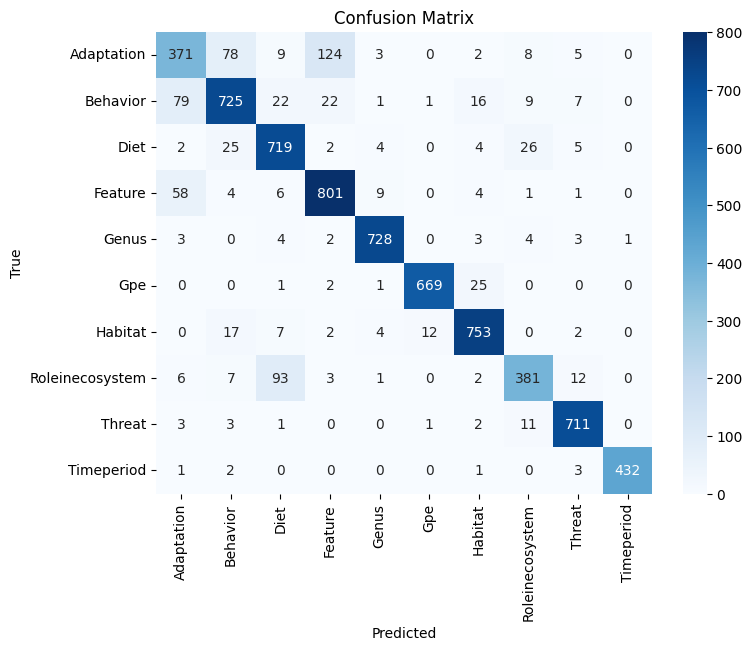

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels= encoder.classes_, yticklabels= encoder.classes_, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

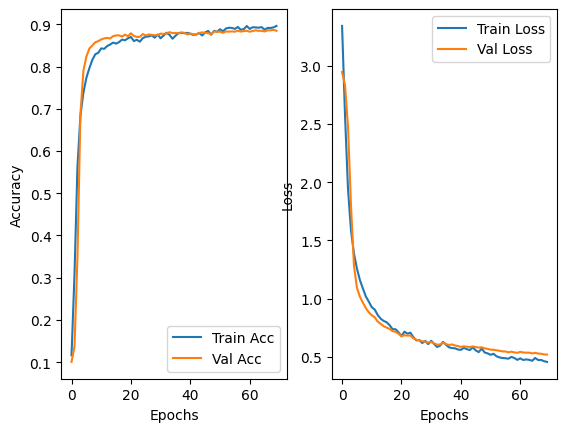

In [12]:
# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [13]:
ANN = tf.keras.models.load_model('/content/NER_Model.keras')

In [14]:
print("Train embeddings:", X_train_embeddings.shape)
print("Test embeddings:", X_test_embeddings.shape)
y_pred_probs = ANN.predict(X_test_embeddings)
print("y_pred_probs shape:", y_pred_probs.shape)

Train embeddings: (21216, 384)
Test embeddings: (7072, 384)
221/221 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
y_pred_probs shape: (7072, 10)


In [15]:
encoder.classes_

array(['Adaptation', 'Behavior', 'Diet', 'Feature', 'Genus', 'Gpe',
       'Habitat', 'Roleinecosystem', 'Threat', 'Timeperiod'], dtype=object)

In [16]:
def classify_text(text, embedder, ann_model, encoder):
    words = re.findall(r'\b\w+\b', text.lower())
    label_counts = Counter()
    for word in words:
        embedding = embedder.encode([word])
        probs = ann_model.predict(embedding, verbose=0)[0]
        label_idx = np.argmax(probs)
        label = encoder.classes_[label_idx]
        label_counts[label] += 1
    final_label = label_counts.most_common(1)[0][0] if label_counts else "Unknown"
    return final_label, dict(label_counts)
def predict_word(word, embedder, ann_model, encoder, top_k=3):
    embedding = embedder.encode([word])
    probs = ann_model.predict(embedding)[0]
    top_k_indices = np.argsort(probs)[::-1][:top_k]
    results = {encoder.classes_[i]: float(probs[i]) for i in top_k_indices}
    return results
unseen_words = ["forest", "lion", "Africa", "herbivore", "Jurassic"]
for word in unseen_words:
    predictions = predict_word(word, model, ANN, encoder, top_k=3)
    print(f"\nWord: {word}")
    for label, prob in predictions.items():
        print(f"  {label}: {prob:.4f}")
sample_text = "Tigers are carnivores found in dense forests and grasslands of Asia."
label, counts = classify_text(sample_text, model, ANN, encoder)
print("Text:", sample_text)
print("Predicted Label:", label)
print("Label Counts:", counts)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 659ms/step

Word: forest
  Habitat: 0.9991
  Gpe: 0.0006
  Behavior: 0.0002
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

Word: lion
  Genus: 0.6522
  Roleinecosystem: 0.1309
  Diet: 0.1034
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

Word: Africa
  Gpe: 0.9999
  Genus: 0.0000
  Habitat: 0.0000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

Word: herbivore
  Diet: 0.5084
  Roleinecosystem: 0.4669
  Behavior: 0.0202
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

Word: Jurassic
  Timeperiod: 0.9998
  Genus: 0.0001
  Adaptation: 0.0000
Text: Tigers are carnivores found in dense forests and grasslands of Asia.
Predicted Label: Habitat
Label Counts: {'Genus': 1, 'Behavior': 1, 'Roleinecosystem': 1, 'Feature': 1, 'Habitat': 5, 'Diet': 1, 'Gpe': 1}


In [17]:
import wikipediaapi
animal_name = "antelope"
wiki = wikipediaapi.Wikipedia(
    language='en',
    user_agent='MyWikiApp/1.0 (https://github.com/myusername/myrepo; myemail@example.com)'
)
page = wiki.page(animal_name)
summary_sentences = page.summary.split(". ")

In [18]:
summary_sentences[1:10]

['Antelopes do not form a monophyletic group, as some antelopes are more closely related to other bovid groups, such as bovines, goats, and sheep, than to other antelopes',
 '\nA stricter grouping, known as the true antelopes, includes only the genera Gazella, Nanger, Eudorcas, and Antilope',
 'One North American mammal, the pronghorn or "pronghorn antelope", is colloquially referred to as the "American antelope", despite the fact that it belongs to a completely different family (Antilocapridae) than the true Old-World antelopes; pronghorn are the sole extant member of a lineage that once included many species which went extinct in the prehistoric period.\nAlthough antelopes are sometimes misidentified as "deer" (cervids), the groups are only distantly related',
 'While antelopes are found in abundance in Africa, there is only one living African deer species: the Barbary stag of North Africa',
 'By comparison, numerous deer species are found in regions of the world with few or no antel

In [19]:
def sentence_to_embedding(sentence, model, embedding_dim=384):
    words = nltk.word_tokenize(sentence)
    stop = nltk.corpus.stopwords.words('english')
    words = [word for word in words if word.lower() not in stop and word.isalnum()]
    if not words:
        return np.zeros((1, embedding_dim))
    embeddings = model.encode(words)
    if embeddings.ndim == 1:  # single vector
        embeddings = embeddings[np.newaxis, :]
    mean_embedding = embeddings.mean(axis=0)
    return mean_embedding.reshape(1, -1)

# Prediction
sentence = summary_sentences[6]
embedding = sentence_to_embedding(sentence, model)
pred = ANN.predict(embedding)
pred_label_idx = np.argmax(pred, axis=1)
pred_label = encoder.inverse_transform(pred_label_idx)[0]
pred_label

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


'Habitat'

In [20]:
encoder.classes_

array(['Adaptation', 'Behavior', 'Diet', 'Feature', 'Genus', 'Gpe',
       'Habitat', 'Roleinecosystem', 'Threat', 'Timeperiod'], dtype=object)

In [21]:
sentence

'This is likely due to competition over shared resources, as deer and antelope fill a virtually identical ecological niche in their respective habitats'